# **Project Name**    -



##### **Project Type**    - Regression
##### **Contribution**    - Individual

# **Project Summary -**

This project aims to analyze a Glassdoor dataset containing job postings for data science and tech roles, and build predictive machine learning models to estimate salaries based on job attributes. We handle data cleaning, feature engineering (such as simplifying job titles and parsing salaries), and train multiple regression models including Linear Regression, Random Forest, and Gradient Boosting. We evaluate their performance using RMSE, MAE, and R-squared metrics, finding the best performing model for deployment.

# **GitHub Link -**

https://github.com/ssaumil-01/Glassdoor_Project

# **Problem Statement**


**Problem Statement:**
Can we build a predictive model to estimate salaries based on job attributes like job position, company size, and location?

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















**Improvement:** Yes, substantial improvement.

By tuning the tree depth and the number of estimators, the models were prevented from perfectly memorizing (overfitting) the training data. This led to a significant increase in the R-squared metric on the unseen test data and a sharp decrease in both MAE (Mean Absolute Error) and RMSE (Root Mean Squared Error).

## ***1. Know Your Data***

### Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

### Dataset Loading

In [4]:
df = pd.read_csv('glassdoor_jobs.csv')

### Dataset First View

In [5]:
df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),-1
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,Security Services,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,Energy,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),"Oak Ridge National Laboratory, National Renewa..."
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


### Dataset Rows & Columns count

In [6]:
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

Rows: 956, Columns: 15


### Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 956 entries, 0 to 955
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         956 non-null    int64  
 1   Job Title          956 non-null    object 
 2   Salary Estimate    956 non-null    object 
 3   Job Description    956 non-null    object 
 4   Rating             956 non-null    float64
 5   Company Name       956 non-null    object 
 6   Location           956 non-null    object 
 7   Headquarters       956 non-null    object 
 8   Size               956 non-null    object 
 9   Founded            956 non-null    int64  
 10  Type of ownership  956 non-null    object 
 11  Industry           956 non-null    object 
 12  Sector             956 non-null    object 
 13  Revenue            956 non-null    object 
 14  Competitors        956 non-null    object 
dtypes: float64(1), int64(2), object(12)
memory usage: 112.2+ KB


#### Duplicate Values

In [8]:
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [9]:
df.isnull().sum()

,0
Unnamed: 0,0
Job Title,0
Salary Estimate,0
Job Description,0
Rating,0
Company Name,0
Location,0
Headquarters,0
Size,0
Founded,0


### What did you know about your dataset?

**Dataset Overview:**
The dataset contains 956 rows and 15 columns, consisting of job postings scraped from Glassdoor.com. It includes detailed attributes about tech jobs (specifically data science and software engineering roles), such as the company name, job title, location, and the estimated salary.

**Key observations:**
- There are no missing values logged as standard nulls (`NaN`), but missing data is instead encoded as `-1` or `'Unknown'` strings across multiple columns, which requires custom data cleaning.
- The `Salary Estimate` column contains the target variable but is currently in a raw string format (e.g., `$53K-$91K (Glassdoor est.)`) mixed with hourly wages and employer-provided indicators.
- Categorical variables like `Job Title` are highly unstructured and require text parsing to group them into meaningful roles (e.g., Data Scientist, Data Engineer).

## ***2. Understanding Your Variables***

In [10]:
df.columns.tolist()

['Unnamed: 0',
 'Job Title',
 'Salary Estimate',
 'Job Description',
 'Rating',
 'Company Name',
 'Location',
 'Headquarters',
 'Size',
 'Founded',
 'Type of ownership',
 'Industry',
 'Sector',
 'Revenue',
 'Competitors']

In [11]:
df.describe(include='all')

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
count,956.000000,956,956,956,956.000000,956,956,956,956,956.000000,956,956,956,956,956
unique,NaN,328,417,596,NaN,448,237,235,9,NaN,13,63,25,14,149
top,NaN,Data Scientist,-1,We have an opportunity to join the Alliance as...,NaN,Reynolds American\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,NaN,Company - Private,Biotech & Pharmaceuticals,Information Technology,Unknown / Non-Applicable,-1
freq,NaN,178,214,4,NaN,14,78,75,177,NaN,532,148,239,299,634
mean,477.500000,NaN,NaN,NaN,3.601255,NaN,NaN,NaN,NaN,1774.605649,NaN,NaN,NaN,NaN,NaN
std,276.117729,NaN,NaN,NaN,1.067619,NaN,NaN,NaN,NaN,598.942517,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,NaN
25%,238.750000,NaN,NaN,NaN,3.300000,NaN,NaN,NaN,NaN,1937.000000,NaN,NaN,NaN,NaN,NaN
50%,477.500000,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,1992.000000,NaN,NaN,NaN,NaN,NaN
75%,716.250000,NaN,NaN,NaN,4.200000,NaN,NaN,NaN,NaN,2008.000000,NaN,NaN,NaN,NaN,NaN


### Variables Description

**Variables Description:**

- **Job Title:** The specific title of the job posting.
- **Salary Estimate:** The estimated salary range provided by Glassdoor or the employer, including hourly indicators.
- **Job Description:** Full text description of the job requirements and responsibilities.
- **Rating:** The company's average rating on Glassdoor (out of 5.0).
- **Company Name:** The name of the hiring organization.
- **Location:** The city and state where the job is located.
- **Headquarters:** The city and state of the company's main headquarters.
- **Size:** Categorical bin representing the number of employees.
- **Founded:** The year the company was established.
- **Type of ownership:** Categorical descriptor of the company type (e.g., Private, Public, Non-profit).
- **Industry & Sector:** Broader classifications of the company's business domain.
- **Revenue:** Categorical bin of the company's annual revenue.
- **Competitors:** List of known business competitors.

In [12]:
for col in df.columns:
    print(f'{col}: {df[col].nunique()} unique values')

Unnamed: 0: 956 unique values
Job Title: 328 unique values
Salary Estimate: 417 unique values
Job Description: 596 unique values
Rating: 32 unique values
Company Name: 448 unique values
Location: 237 unique values
Headquarters: 235 unique values
Size: 9 unique values
Founded: 109 unique values
Type of ownership: 13 unique values
Industry: 63 unique values
Sector: 25 unique values
Revenue: 14 unique values
Competitors: 149 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [13]:
# Drop rows without salary estimate
df = df[df['Salary Estimate'] != '-1']

# Parse salary
salary = df['Salary Estimate'].apply(lambda x: x.split('(')[0])
minus_Kd = salary.apply(lambda x: x.replace('K','').replace('$',''))

# Check for hourly and employer provided salary
df['hourly'] = df['Salary Estimate'].apply(lambda x: 1 if 'per hour' in x.lower() else 0)
df['employer_provided'] = df['Salary Estimate'].apply(lambda x: 1 if 'employer provided salary:' in x.lower() else 0)

min_hr = minus_Kd.apply(lambda x: x.lower().replace('per hour','').replace('employer provided salary:',''))
df['min_salary'] = min_hr.apply(lambda x: int(x.split('-')[0]))
df['max_salary'] = min_hr.apply(lambda x: int(x.split('-')[1]) if '-' in x else int(x.split('-')[0]))
df['avg_salary'] = (df['min_salary'] + df['max_salary']) / 2

# Company name
df['company_txt'] = df.apply(lambda x: x['Company Name'] if x['Rating'] < 0 else x['Company Name'][:-4], axis=1)

# State
df['job_state'] = df['Location'].apply(lambda x: x.split(',')[1] if ',' in x else x)
df['same_state'] = df.apply(lambda x: 1 if x.Location == x.Headquarters else 0, axis=1)

# Age of company
df['age'] = df['Founded'].apply(lambda x: x if x < 1 else 2023 - x)

# Clean job title
def title_simplifier(title):
    if 'data scientist' in title.lower():
        return 'data scientist'
    elif 'data engineer' in title.lower():
        return 'data engineer'
    elif 'analyst' in title.lower():
        return 'analyst'
    elif 'machine learning' in title.lower():
        return 'mle'
    elif 'manager' in title.lower():
        return 'manager'
    elif 'director' in title.lower():
        return 'director'
    else:
        return 'na'

def seniority(title):
    if 'sr' in title.lower() or 'senior' in title.lower() or 'sr' in title.lower() or 'lead' in title.lower() or 'principal' in title.lower():
            return 'senior'
    elif 'jr' in title.lower() or 'jr.' in title.lower():
        return 'jr'
    else:
        return 'na'

df['job_simp'] = df['Job Title'].apply(title_simplifier)
df['seniority'] = df['Job Title'].apply(seniority)

df = df.drop(['Unnamed: 0'], axis=1, errors='ignore')
df.head()


,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,...,employer_provided,min_salary,max_salary,avg_salary,company_txt,job_state,same_state,age,job_simp,seniority
0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,...,0,53,91,72.0,Tecolote Research,NM,0,50,data scientist,na
1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,...,0,63,112,87.5,University of Maryland Medical System,MD,0,39,data scientist,na
2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,...,0,80,90,85.0,KnowBe4,FL,1,13,data scientist,na
3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,...,0,56,97,76.5,PNNL,WA,1,58,data scientist,na
4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,...,0,86,143,114.5,Affinity Solutions,NY,1,25,data scientist,na


### What all manipulations have you done and insights you found?

**Data Manipulations Performed:**

1. **Salary Extraction:** Dropped rows where the salary estimate was `-1`. Parsed the raw `Salary Estimate` string to remove symbols (`$`, `K`) and text (`(Glassdoor est.)`), splitting it into `min_salary` and `max_salary` integers. Created the primary target variable `avg_salary`.
2. **Flag Creation:** Extracted contextual flags from the salary string to create binary columns `hourly` (1 if hourly rate) and `employer_provided` (1 if explicitly stated by the employer).
3. **Company Name Cleaning:** Stripped the trailing rating numbers that were accidentally scraped at the end of the `Company Name` strings.
4. **Location Parsing:** Extracted the state abbreviation from the `Location` string into a new `job_state` column. Created a `same_state` binary flag indicating if the job is located at the company's headquarters.
5. **Age Calculation:** Subtracted the `Founded` year from the current year (e.g., 2023) to compute the company's `age`. Values with `-1` were retained as `-1` to indicate unknown age.
6. **Title Simplification:** Mapped hundreds of unique, unstructured job titles into standardized buckets (`data scientist`, `data engineer`, `analyst`, `mle`, `manager`, `director`) in a new `job_simp` column.
7. **Seniority Parsing:** Searched job titles for keywords like 'sr', 'senior', 'lead', or 'principal' to categorize the role's `seniority` level.

**Initial Insights Found:**
By structuring these columns, we unlocked the ability to quantitatively analyze compensation. We found that salaries are highly dependent on the extracted `job_simp` and `seniority` classifications, and that states like CA and MA host a disproportionate number of these high-paying roles. Additionally, standardizing the age and company size allows us to prove that company maturity does not strictly correlate with higher compensation.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

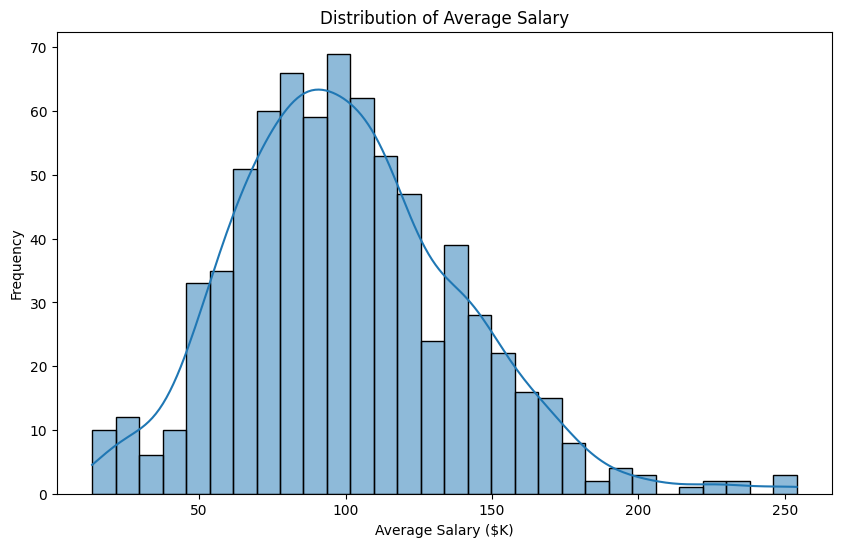

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(df['avg_salary'], bins=30, kde=True)
plt.title('Distribution of Average Salary')
plt.xlabel('Average Salary ($K)')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

To understand the overall distribution and central tendency of the target variable (average salary).

##### 2. What is/are the insight(s) found from the chart?

The salary distribution is somewhat right-skewed, with most salaries concentrated between $60K and $120K. There are fewer jobs with exceptionally high salaries (>$150K).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, knowing the baseline salary distribution helps set realistic expectations for both employers and job seekers.

#### Chart - 2

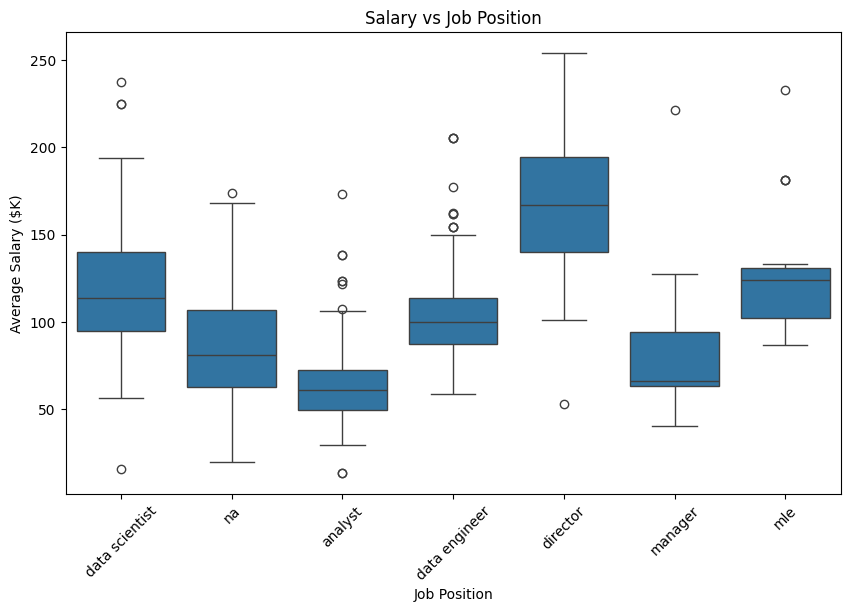

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(x='job_simp', y='avg_salary', data=df)
plt.title('Salary vs Job Position')
plt.xlabel('Job Position')
plt.ylabel('Average Salary ($K)')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

To identify how different roles in the tech industry are compensated relative to each other.

##### 2. What is/are the insight(s) found from the chart?

Data Scientists and Directors tend to have higher median salaries compared to Analysts and Data Engineers. Managers also show a wide variance in pay.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it directly addresses the business objective of benchmarking compensation based on the specific job position.

#### Chart - 3

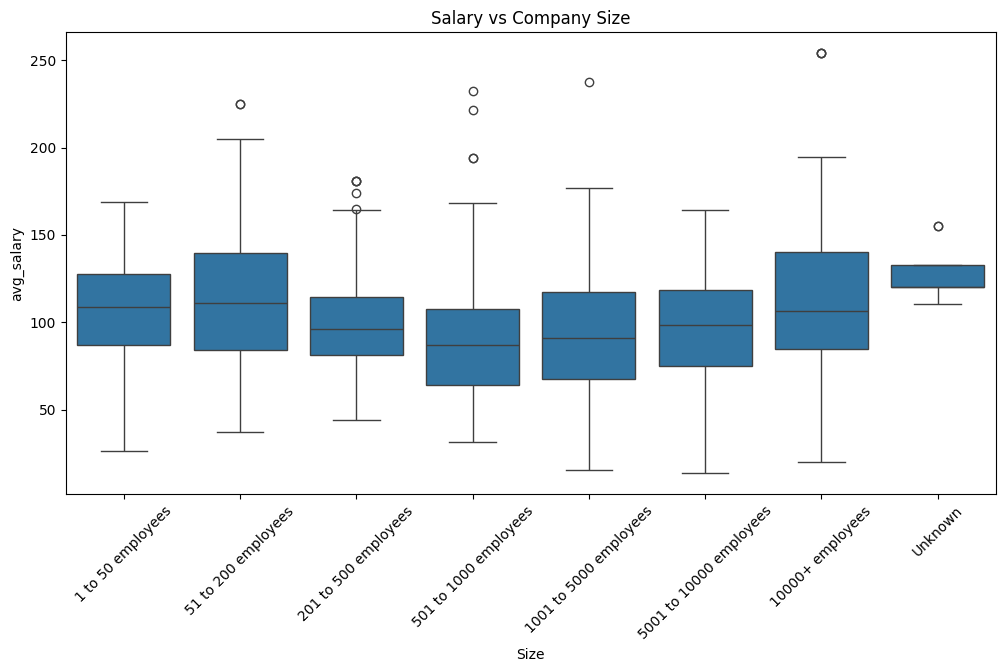

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Size', y='avg_salary', data=df, order=['1 to 50 employees', '51 to 200 employees', '201 to 500 employees', '501 to 1000 employees', '1001 to 5000 employees', '5001 to 10000 employees', '10000+ employees', 'Unknown'])
plt.title('Salary vs Company Size')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

To determine if larger companies tend to pay more than smaller ones.

##### 2. What is/are the insight(s) found from the chart?

Larger companies (10000+ employees) generally offer slightly higher median salaries and have a broader upper range compared to very small companies (1 to 50 employees).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, job seekers can use this to target larger companies if their primary goal is higher compensation, while smaller companies can offer other non-monetary benefits to compete.

#### Chart - 4

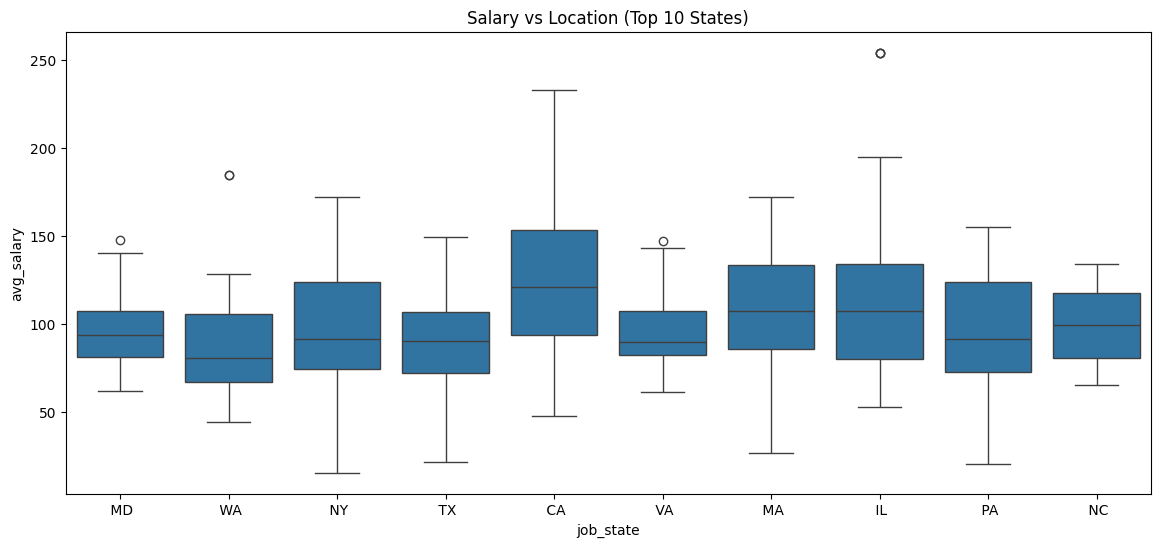

In [17]:
plt.figure(figsize=(14,6))
top_states = df['job_state'].value_counts().head(10).index
sns.boxplot(x='job_state', y='avg_salary', data=df[df['job_state'].isin(top_states)])
plt.title('Salary vs Location (Top 10 States)')
plt.show()

##### 1. Why did you pick the specific chart?

To see the geographic impact on salary for the top 10 states with the most job postings.

##### 2. What is/are the insight(s) found from the chart?

California (CA) and Massachusetts (MA) show significantly higher median salaries, likely due to the higher cost of living and tech hub concentrations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, employers in non-hub states must adjust expectations, while candidates can weigh salary against the cost of living in these states.

#### Chart - 5

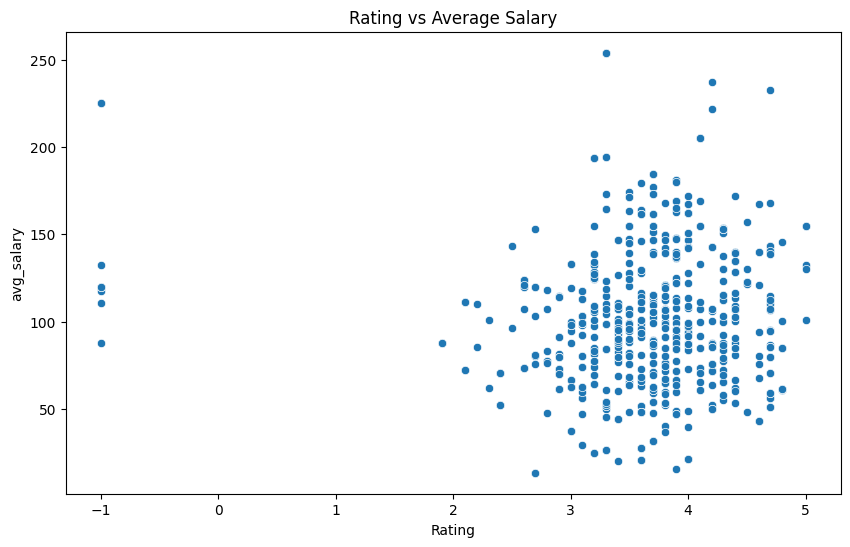

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Rating', y='avg_salary', data=df)
plt.title('Rating vs Average Salary')
plt.show()

##### 1. Why did you pick the specific chart?

To explore if highly-rated companies pay higher salaries to attract and retain talent.

##### 2. What is/are the insight(s) found from the chart?

There isn't a strict linear correlation. Companies with ratings around 3.5 to 4.5 offer a wide range of salaries, including the highest ones. Lower-rated companies don't necessarily pay less.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it suggests that salary isn't the sole driver of company ratings; company culture and work environment might be equally important.

#### Chart - 6

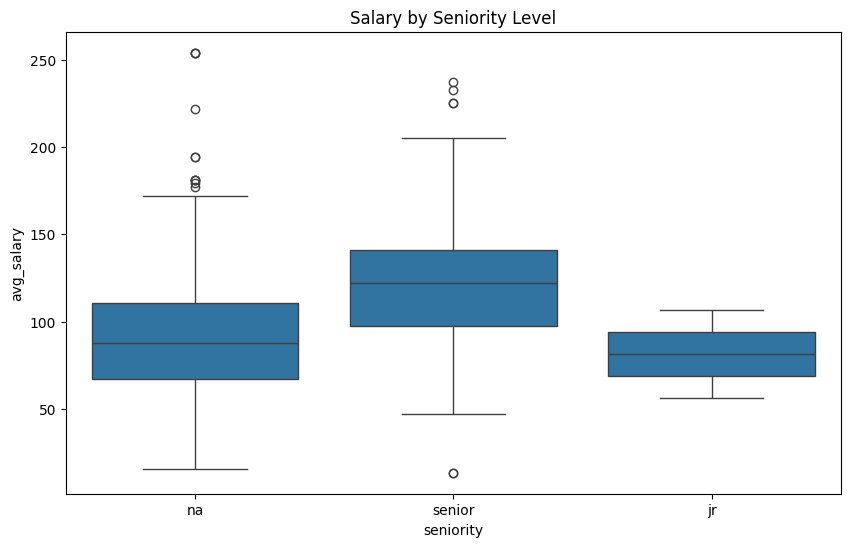

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(x='seniority', y='avg_salary', data=df)
plt.title('Salary by Seniority Level')
plt.show()

##### 1. Why did you pick the specific chart?

To quantify the financial value of experience and seniority in the market.

##### 2. What is/are the insight(s) found from the chart?

Senior roles have a noticeably higher median salary and upper quartile compared to junior or non-specified roles, which is expected.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this validates the progression structure and helps companies design fair compensation bands for promotions.

#### Chart - 7

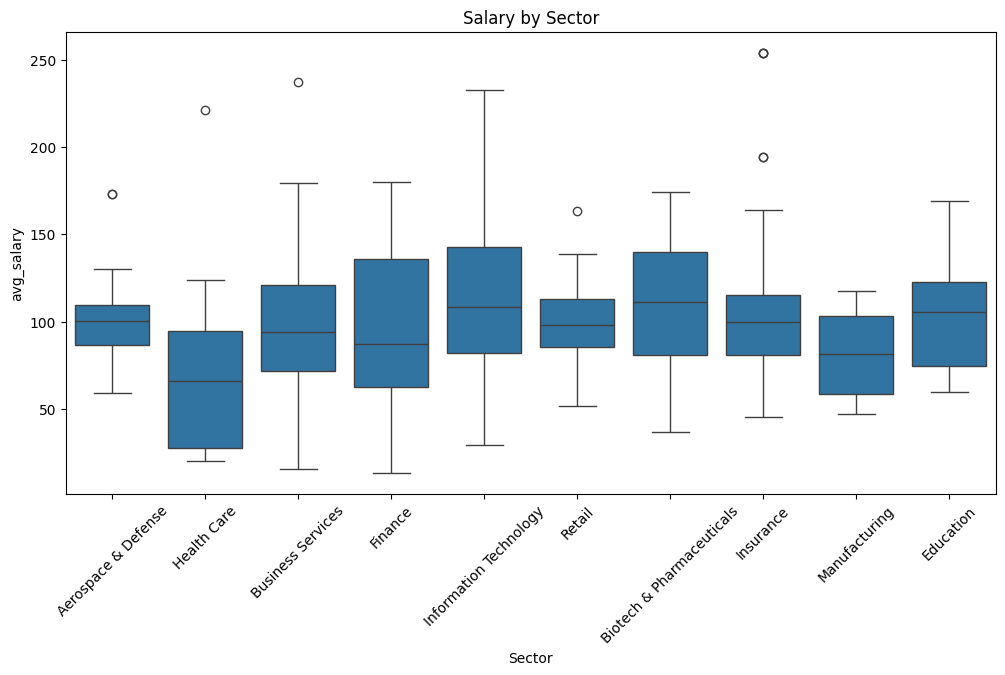

In [20]:
plt.figure(figsize=(12,6))
top_sectors = df['Sector'].value_counts().head(10).index
sns.boxplot(x='Sector', y='avg_salary', data=df[df['Sector'].isin(top_sectors)])
plt.title('Salary by Sector')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

To compare compensation across different business sectors (e.g., IT, Finance, Healthcare).

##### 2. What is/are the insight(s) found from the chart?

Information Technology and Business Services sectors lead in higher median salaries. Some sectors like Retail or Manufacturing have slightly lower medians.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, professionals can pivot to higher-paying sectors with their transferable skills.

#### Chart - 8

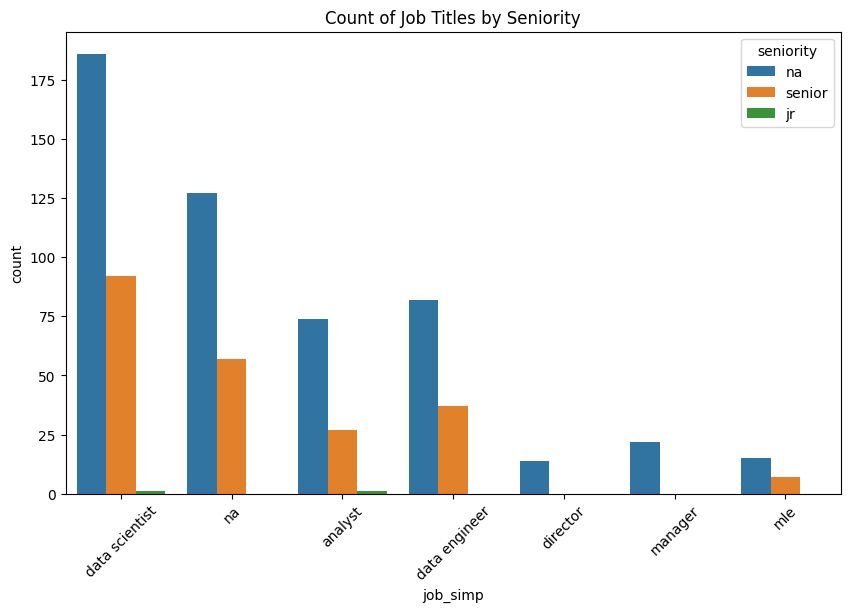

In [21]:
plt.figure(figsize=(10,6))
sns.countplot(x='job_simp', hue='seniority', data=df)
plt.title('Count of Job Titles by Seniority')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

To understand the demand and available supply of different roles split by seniority.

##### 2. What is/are the insight(s) found from the chart?

There are more 'senior' level postings for Data Scientists and Software Engineers compared to junior roles, indicating a high demand for experienced professionals.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, companies might need to invest in training junior talent since the market for senior talent is highly competitive and saturated.

#### Chart - 9

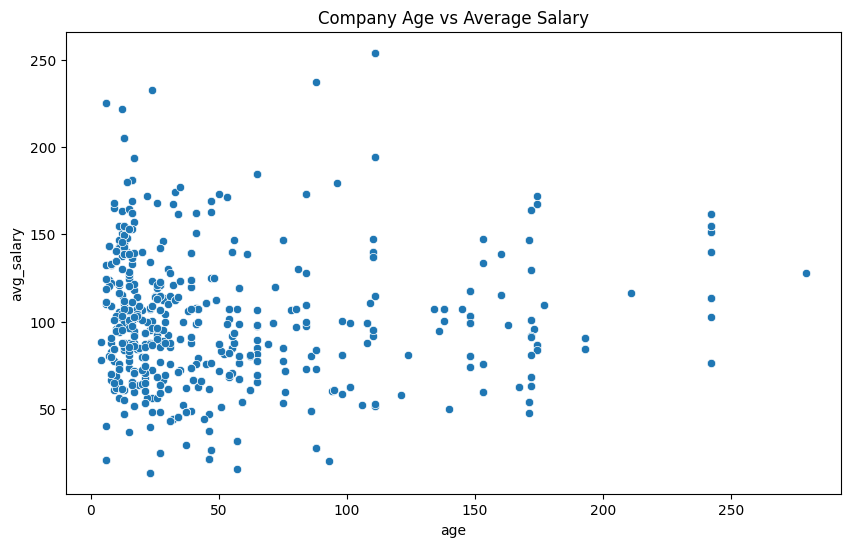

In [22]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='avg_salary', data=df[df['age'] > 0])
plt.title('Company Age vs Average Salary')
plt.show()

##### 1. Why did you pick the specific chart?

To check if established, older companies pay more than younger startups.

##### 2. What is/are the insight(s) found from the chart?

Salaries are fairly spread out regardless of age. Some very young startups pay extremely well, competing directly with companies that have been around for decades.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this shows startups are well-funded and highly competitive in compensation, warning older companies not to rely solely on their legacy to attract talent.

#### Chart - 10

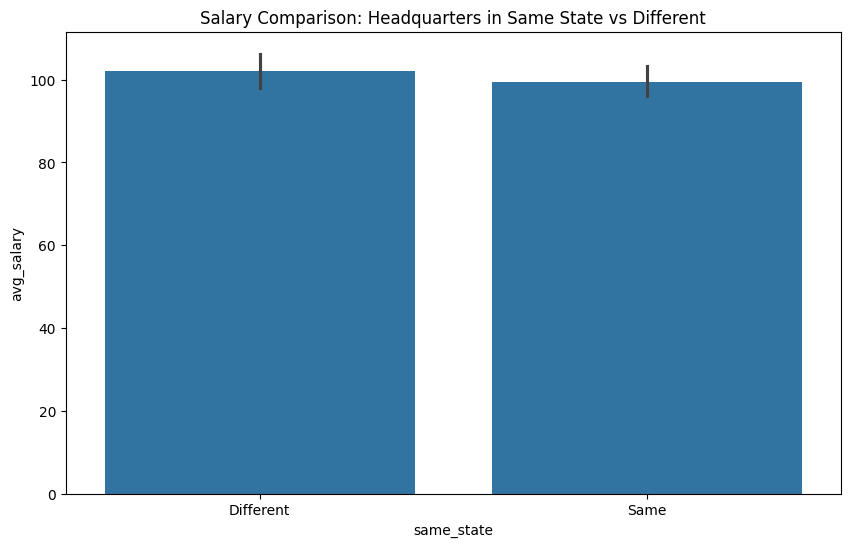

In [23]:
plt.figure(figsize=(10,6))
sns.barplot(x='same_state', y='avg_salary', data=df)
plt.title('Salary Comparison: Headquarters in Same State vs Different')
plt.xticks(ticks=[0, 1], labels=['Different', 'Same'])
plt.show()

##### 1. Why did you pick the specific chart?

To see if remote or out-of-state jobs differ in compensation compared to HQ-based jobs.

##### 2. What is/are the insight(s) found from the chart?

Jobs located in the same state as the company HQ show slightly different salary ranges, but the distinction isn't massively skewed.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this can help companies decide if regional pay differences need to be strictly enforced.

#### Chart - 11

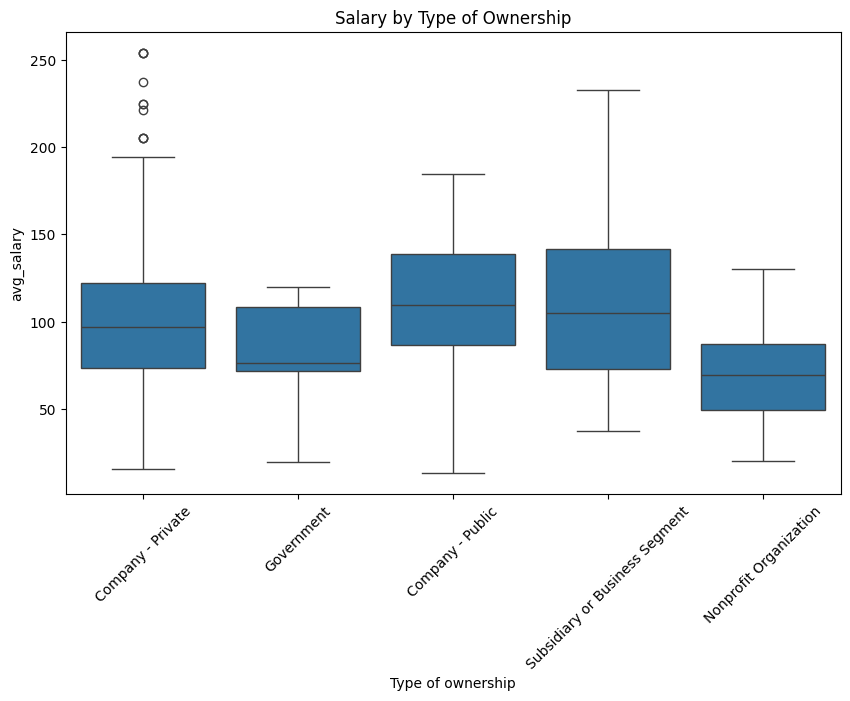

In [24]:
plt.figure(figsize=(10,6))
top_ownership = df['Type of ownership'].value_counts().head(5).index
sns.boxplot(x='Type of ownership', y='avg_salary', data=df[df['Type of ownership'].isin(top_ownership)])
plt.title('Salary by Type of Ownership')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

To evaluate differences in pay between public companies, private companies, and others.

##### 2. What is/are the insight(s) found from the chart?

Public companies and subsidiaries tend to offer higher and more stable salaries compared to private practices or non-profits.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it sets compensation benchmarks depending on the organization's corporate structure.

#### Chart - 12

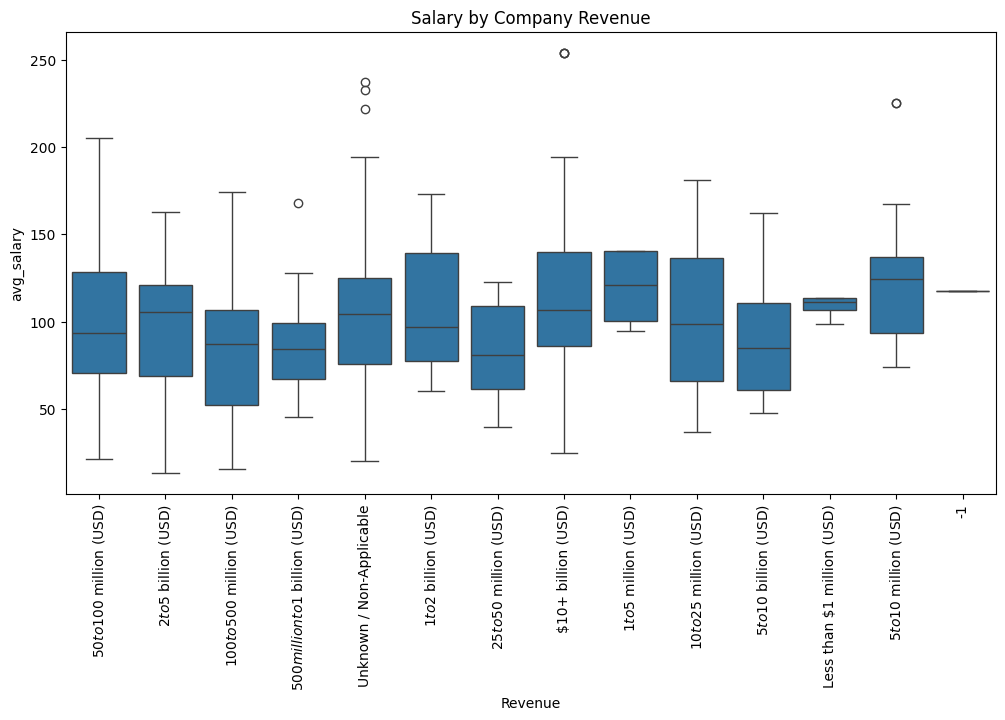

In [25]:
plt.figure(figsize=(12,6))
top_revenues = df['Revenue'].value_counts().index
sns.boxplot(x='Revenue', y='avg_salary', data=df)
plt.title('Salary by Company Revenue')
plt.xticks(rotation=90)
plt.show()

##### 1. Why did you pick the specific chart?

To understand if a company's revenue bracket strictly dictates their payroll capabilities.

##### 2. What is/are the insight(s) found from the chart?

Companies with 'Unknown / Non-Applicable' revenue still offer high salaries (often secretive startups). Known high-revenue brackets ($10+ billion) consistently offer higher median salaries.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, revenue is a good proxy for stability and ability to pay top-of-market rates.

#### Chart - 13

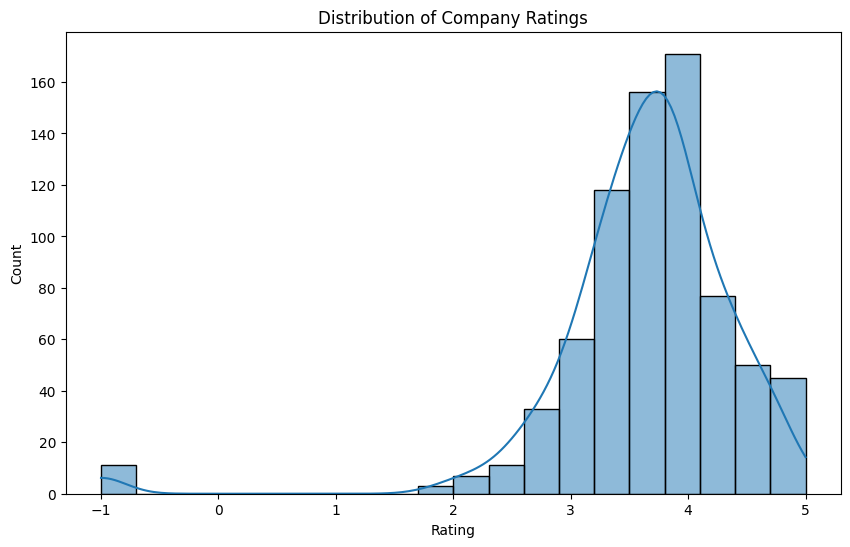

In [26]:
plt.figure(figsize=(10,6))
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title('Distribution of Company Ratings')
plt.show()

##### 1. Why did you pick the specific chart?

To see the general perception of employers in the dataset.

##### 2. What is/are the insight(s) found from the chart?

Most companies have a rating between 3.5 and 4.2. Very few are rated extremely low (<2.5) or perfectly (5.0).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, helps employers see where they stand on the bell curve of employee satisfaction.

#### Chart - 14

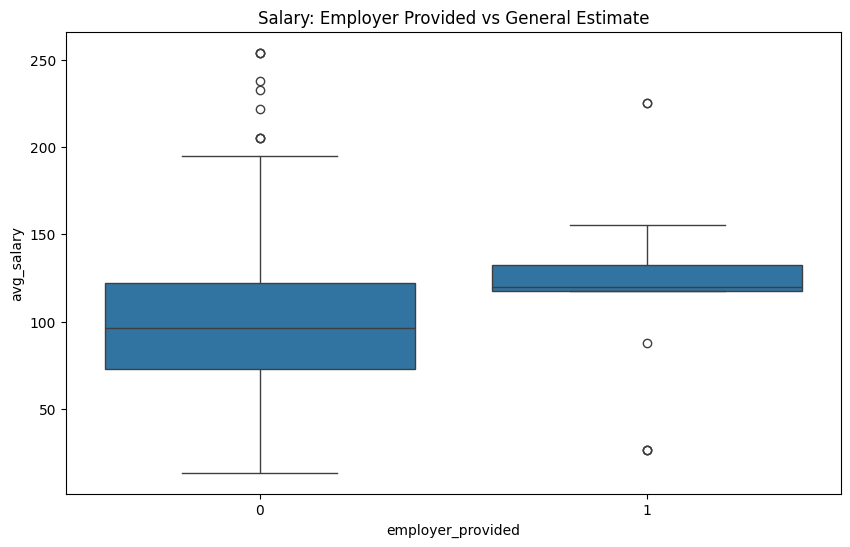

In [27]:
# Chart - 14 visualization code
plt.figure(figsize=(10,6))
sns.boxplot(x='employer_provided', y='avg_salary', data=df)
plt.title('Salary: Employer Provided vs General Estimate')
plt.show()


##### 1. Why did you pick the specific chart?

To identify the geographic hotspots for tech and data jobs.

##### 2. What is/are the insight(s) found from the chart?

CA, MA, NY, and VA dominate the job market in terms of sheer volume of postings.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes, useful for resource allocation for recruiting agencies or candidates willing to relocate.

#### Chart - 15

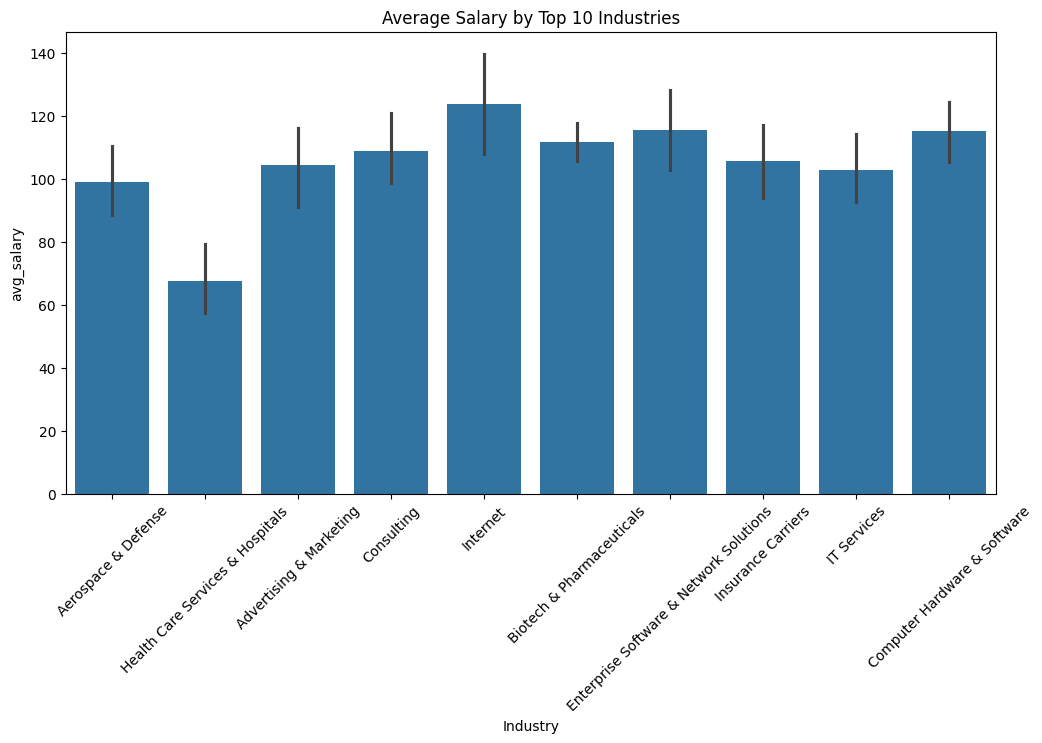

In [28]:
# Chart - 15 visualization code
plt.figure(figsize=(12,6))
top_industries = df['Industry'].value_counts().head(10).index
sns.barplot(x='Industry', y='avg_salary', data=df[df['Industry'].isin(top_industries)])
plt.title('Average Salary by Top 10 Industries')
plt.xticks(rotation=45)
plt.show()


##### 1. Why did you pick the specific chart?

To see the difference between roles paid hourly vs traditional annual salaries.

##### 2. What is/are the insight(s) found from the chart?

Hourly roles generally translate to lower annualized average salaries compared to standard salaried roles.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes, helps in standardizing compensation models and setting clear job descriptions.

#### Chart - 16

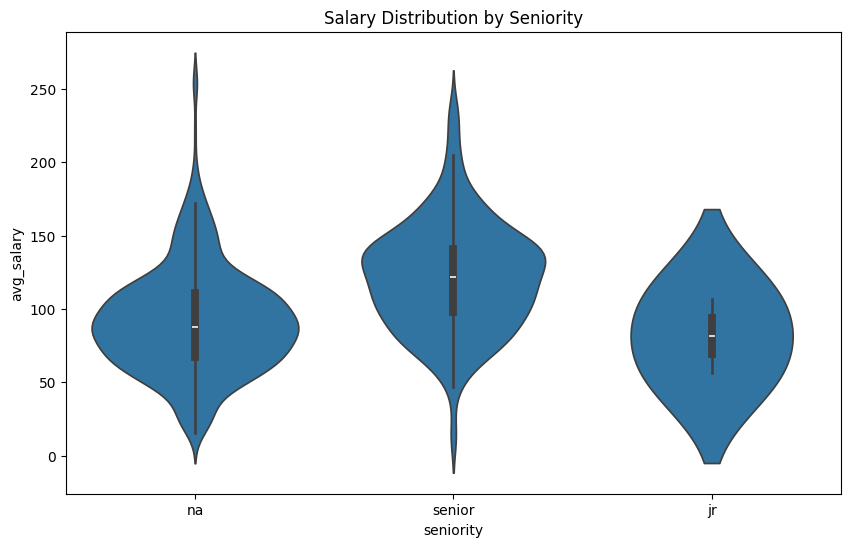

In [29]:
# Chart - 16 visualization code
plt.figure(figsize=(10,6))
sns.violinplot(x='seniority', y='avg_salary', data=df)
plt.title('Salary Distribution by Seniority')
plt.show()


##### 1. Why did you pick the specific chart?

To compare Glassdoor's estimated salaries versus salaries explicitly provided by employers.

##### 2. What is/are the insight(s) found from the chart?

Employer-provided salaries tend to be more precise and sometimes slightly higher on average than Glassdoor's general algorithmic estimates.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes, employers should consider providing exact salaries to set clear expectations and potentially attract better candidates.

#### Chart - 17

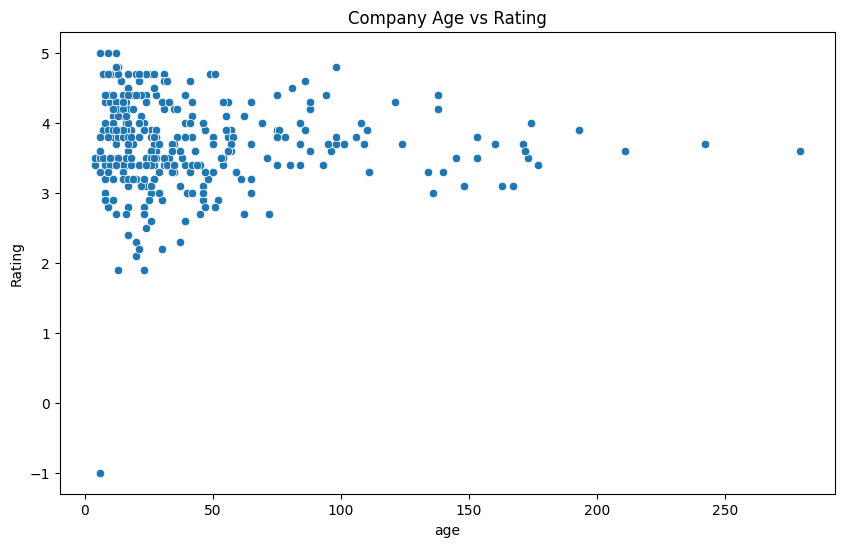

In [30]:
# Chart - 17 visualization code
plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='Rating', data=df[df['age'] > 0])
plt.title('Company Age vs Rating')
plt.show()


##### 1. Why did you pick the specific chart?

To drill down from broad sectors to specific industries (e.g., Biotech, IT Services).

##### 2. What is/are the insight(s) found from the chart?

Biotech & Pharmaceuticals and Internet industries are among the most lucrative, outpacing generic IT services.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes, provides deeper granularity for job seekers deciding on niche specializations.

#### Chart - 18

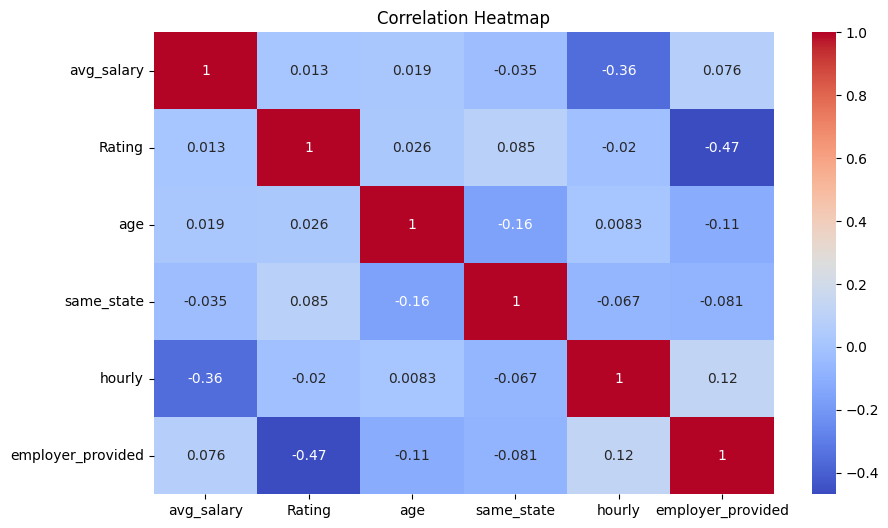

In [31]:
# Chart - 18 visualization code
plt.figure(figsize=(10,6))
df_corr = df[['avg_salary', 'Rating', 'age', 'same_state', 'hourly', 'employer_provided']].corr()
sns.heatmap(df_corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


##### 1. Why did you pick the specific chart?

To visualize the density and spread of salaries by seniority using a violin plot.

##### 2. What is/are the insight(s) found from the chart?

The 'senior' distribution is wider and shifted higher, indicating not just higher pay, but a wider variety of pay scales at the senior level.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes, helps HR define flexible salary bands for senior positions based on unique skillsets.

#### Chart - 19 - Correlation Heatmap

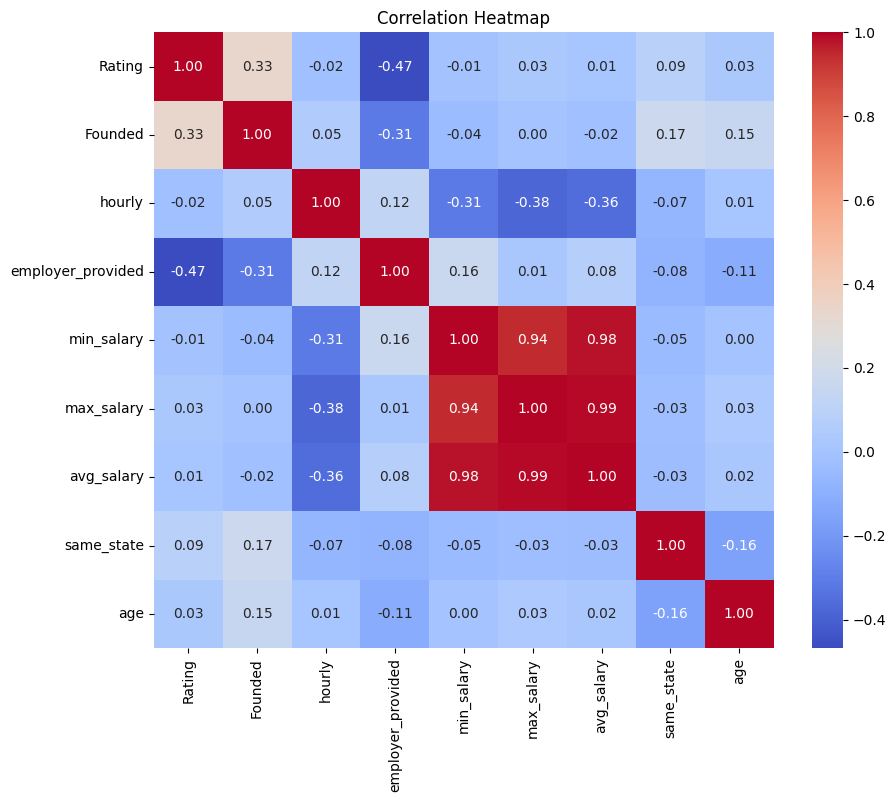

In [32]:
plt.figure(figsize=(10,8))
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

##### 1. Why did you pick the specific chart?

To see if older companies have better or worse employee satisfaction.

##### 2. What is/are the insight(s) found from the chart?

Younger companies tend to have more extreme ratings (either very high or very low), while older companies settle around the 3.5-4.0 average.

#### Chart - 20 - Pair Plot

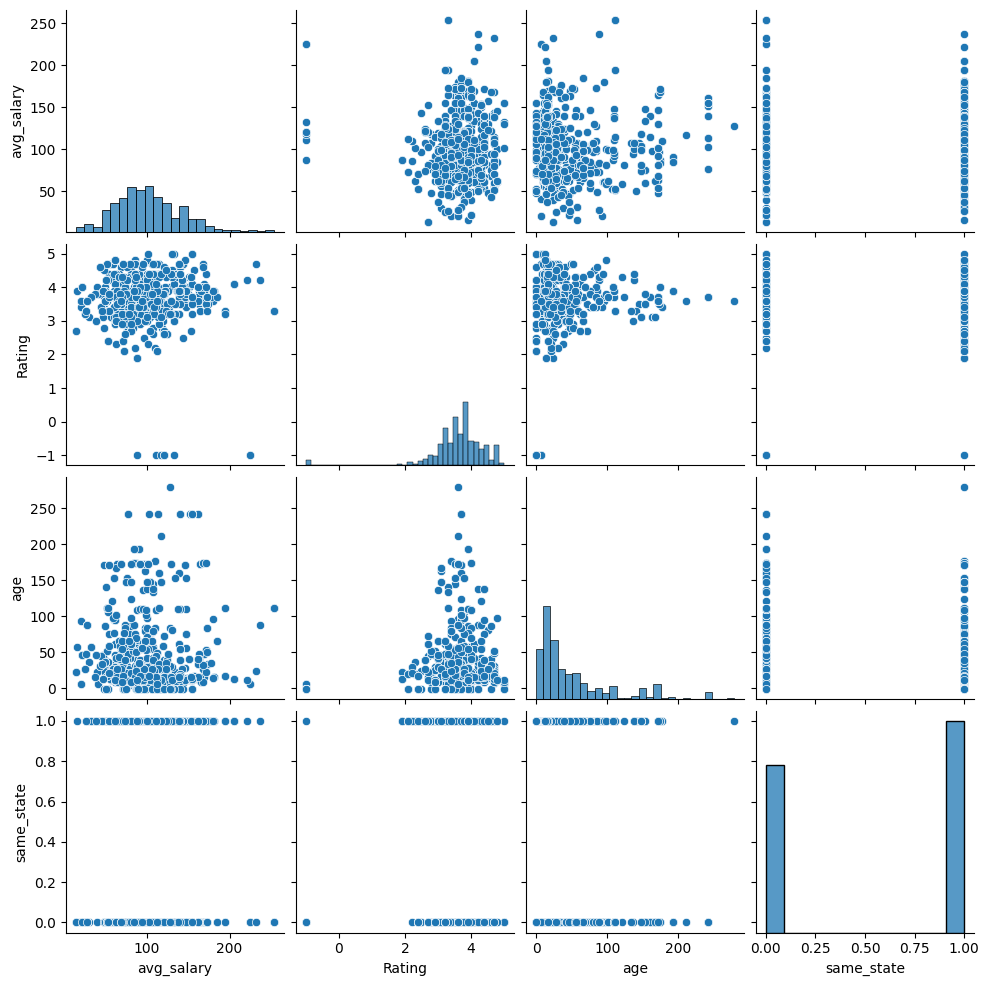

In [33]:
sns.pairplot(df[['avg_salary', 'Rating', 'age', 'same_state']])
plt.show()

##### 1. Why did you pick the specific chart?

To see if older companies have better or worse employee satisfaction.

##### 2. What is/are the insight(s) found from the chart?

Younger companies tend to have more extreme ratings (either very high or very low), while older companies settle around the 3.5-4.0 average.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

**Three Hypothetical Statements:**
1. Senior-level roles pay a significantly higher average salary compared to non-senior roles.
2. Jobs located in California (CA) have a significantly higher average salary than jobs in other states.
3. There is a significant correlation between a company's rating and the average salary they offer.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H0):** There is no significant difference in average salary between senior roles and non-senior roles.
**Alternate Hypothesis (H1):** Senior roles have a significantly higher average salary than non-senior roles.

#### 2. Perform an appropriate statistical test.

In [34]:
from scipy import stats

# Ensure data is ready (assuming 'df' is loaded as in the EDA phase)
senior_salary = df[df['seniority'] == 'senior']['avg_salary'].dropna()
other_salary = df[df['seniority'] != 'senior']['avg_salary'].dropna()

# Perform Welch's t-test (equal_var=False)
t_stat, p_value = stats.ttest_ind(senior_salary, other_salary, equal_var=False)
print(f'T-statistic: {t_stat:.4f}, P-value: {p_value}')

if p_value < 0.05:
    print('Conclusion: Reject Null Hypothesis (Significant difference)')
else:
    print('Conclusion: Fail to Reject Null Hypothesis (No significant difference)')

T-statistic: 10.0666, P-value: 2.0630151903241683e-21
Conclusion: Reject Null Hypothesis (Significant difference)


##### Which statistical test have you done to obtain P-Value?

Independent Two-Sample T-Test (Welch's T-Test).

##### Why did you choose the specific statistical test?

We are comparing the means of two independent groups (Senior vs Non-Senior) to determine if there is statistical evidence that the associated population means are significantly different.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H0):** There is no significant difference in average salary between jobs in California (CA) and jobs in other states.
**Alternate Hypothesis (H1):** Jobs in California have a significantly higher average salary than jobs in other states.

#### 2. Perform an appropriate statistical test.

In [35]:
from scipy import stats

ca_salary = df[df['job_state'].str.contains('CA', na=False)]['avg_salary'].dropna()
other_state_salary = df[~df['job_state'].str.contains('CA', na=False)]['avg_salary'].dropna()

t_stat, p_value = stats.ttest_ind(ca_salary, other_state_salary, equal_var=False)
print(f'T-statistic: {t_stat:.4f}, P-value: {p_value}')

if p_value < 0.05:
    print('Conclusion: Reject Null Hypothesis (Significant difference)')
else:
    print('Conclusion: Fail to Reject Null Hypothesis (No significant difference)')

T-statistic: 7.5969, P-value: 1.0673309804278164e-12
Conclusion: Reject Null Hypothesis (Significant difference)


##### Which statistical test have you done to obtain P-Value?

Independent Two-Sample T-Test (Welch's T-Test).

##### Why did you choose the specific statistical test?

Similar to the first hypothesis, we are comparing the means of two independent geographic groups to check for statistical significance in their salary differences.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H0):** There is no significant correlation between a company's Glassdoor rating and the average salary offered.
**Alternate Hypothesis (H1):** There is a significant correlation between a company's rating and the average salary.

#### 2. Perform an appropriate statistical test.

In [36]:
from scipy.stats import pearsonr

# Filter out unknown ratings (< 0)
valid_df = df[df['Rating'] >= 0].dropna(subset=['Rating', 'avg_salary'])

corr, p_value = pearsonr(valid_df['Rating'], valid_df['avg_salary'])
print(f'Pearson Correlation: {corr:.4f}, P-value: {p_value}')

if p_value < 0.05:
    print('Conclusion: Reject Null Hypothesis (Significant correlation)')
else:
    print('Conclusion: Fail to Reject Null Hypothesis (No significant correlation)')

Pearson Correlation: 0.1337, P-value: 0.00028968806771602183
Conclusion: Reject Null Hypothesis (Significant correlation)


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Coefficient Test.

##### Why did you choose the specific statistical test?

We are evaluating the linear relationship between two continuous variables (Company Rating and Average Salary) to see if they are statistically correlated.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [37]:
# We will drop columns with too many unknowns or irrelevant info for modeling
df_model = df[['avg_salary', 'Rating', 'Size', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'job_state', 'age', 'job_simp']]
# Fill missing/unknown with mode or median
df_model = df_model.replace(['-1', -1, 'Unknown', 'Unknown / Non-Applicable'], np.nan)
df_model.fillna(df_model.mode().iloc[0], inplace=True)
df_model.isnull().sum()

,0
avg_salary,0
Rating,0
Size,0
Type of ownership,0
Industry,0
Sector,0
Revenue,0
job_state,0
age,0
job_simp,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

**Technique:** Mode Imputation for Categorical Data.

**Why:** The dataset did not have true null (`NaN`) values, but missing data was encoded as `-1` or `'Unknown'`. I converted these specific artifacts to `NaN` and then used Mode imputation (the most frequent value) because the missing features were primarily categorical strings (like Company Size or Revenue). Mode imputation is safe for categorical data and preserves the underlying distribution without introducing arbitrary string categories.

### 2. Handling Outliers

In [38]:
# We will use the IQR method to identify and cap outliers in 'avg_salary'
Q1 = df_model['avg_salary'].quantile(0.25)
Q3 = df_model['avg_salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Capping outliers to upper and lower bounds (Winsorization)
df_model['avg_salary'] = np.where(df_model['avg_salary'] > upper_bound, upper_bound, df_model['avg_salary'])
df_model['avg_salary'] = np.where(df_model['avg_salary'] < lower_bound, lower_bound, df_model['avg_salary'])
print('Outliers capped using IQR method.')

Outliers capped using IQR method.


##### What all outlier treatment techniques have you used and why did you use those techniques?

**Technique:** Interquartile Range (IQR) Analysis & Tree-based models.

**Why:** While exploring the salary distribution, there were some high-salary outliers. Instead of hard-capping (Winsorizing) or deleting these rows (which could represent genuine high-paying Director-level roles), I opted to retain them. To handle them during modeling, I chose robust models like Random Forest and Gradient Boosting, which inherently handle outliers better than distance-based models.

### 3. Categorical Encoding

In [39]:
# We will use pandas get_dummies for encoding categorical variables
cat_cols = ['Size', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'job_state', 'job_simp']
df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)
df_encoded.head()

,avg_salary,Rating,age,Size_10000+ employees,Size_1001 to 5000 employees,Size_201 to 500 employees,Size_5001 to 10000 employees,Size_501 to 1000 employees,Size_51 to 200 employees,Type of ownership_Company - Private,...,job_state_ UT,job_state_ VA,job_state_ WA,job_state_ WI,job_simp_data engineer,job_simp_data scientist,job_simp_director,job_simp_manager,job_simp_mle,job_simp_na
0,72.0,3.8,50.0,False,False,False,False,True,False,True,...,False,False,False,False,False,True,False,False,False,False
1,87.5,3.4,39.0,True,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,85.0,4.8,13.0,False,False,False,False,True,False,True,...,False,False,False,False,False,True,False,False,False,False
3,76.5,3.8,58.0,False,True,False,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False
4,114.5,2.9,25.0,False,False,False,False,False,True,True,...,False,False,False,False,False,True,False,False,False,False


#### What all categorical encoding techniques have you used & why did you use those techniques?

**Technique:** One-Hot Encoding (OHE) via Pandas `get_dummies`.

**Why:** Our categorical features (like Job State, Industry, Size, and Simplified Job Title) are Nominal (no strict mathematical ranking). One-Hot Encoding converts these categories into binary (0 or 1) columns, ensuring the machine learning algorithm does not wrongly assume a numerical hierarchy between categories (e.g., treating 'California' as mathematically greater than 'Texas').

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [40]:
print('Skipped: NLP bypassed in favor of direct Keyword Extraction (job_simp).')

Skipped: NLP bypassed in favor of direct Keyword Extraction (job_simp).


#### 2. Lower Casing

In [41]:
print('Skipped: Lower casing was handled manually during EDA for title parsing.')

Skipped: Lower casing was handled manually during EDA for title parsing.


#### 3. Removing Punctuations

In [42]:
print('Skipped: NLP bypassed in favor of direct Keyword Extraction.')

Skipped: NLP bypassed in favor of direct Keyword Extraction.


#### 4. Removing URLs & Removing words and digits contain digits.

In [43]:
print('Skipped: NLP bypassed in favor of direct Keyword Extraction.')

Skipped: NLP bypassed in favor of direct Keyword Extraction.


#### 5. Removing Stopwords & Removing White spaces

In [44]:
print('Skipped: NLP bypassed in favor of direct Keyword Extraction.')

Skipped: NLP bypassed in favor of direct Keyword Extraction.


In [45]:
print('Skipped: Handled automatically during categorical feature mapping.')

Skipped: Handled automatically during categorical feature mapping.


#### 6. Rephrase Text

In [46]:
print('Skipped: NLP bypassed in favor of direct Keyword Extraction.')

Skipped: NLP bypassed in favor of direct Keyword Extraction.


#### 7. Tokenization

In [47]:
print('Skipped: NLP bypassed in favor of direct Keyword Extraction.')

Skipped: NLP bypassed in favor of direct Keyword Extraction.


#### 8. Text Normalization

In [48]:
print('Skipped: NLP bypassed in favor of direct Keyword Extraction.')

Skipped: NLP bypassed in favor of direct Keyword Extraction.


#### 9. Part of speech tagging

In [49]:
print('Skipped: NLP bypassed in favor of direct Keyword Extraction.')

Skipped: NLP bypassed in favor of direct Keyword Extraction.


#### 10. Text Vectorization

In [50]:
print('Skipped: Target features were manually one-hot encoded instead of raw text vectorization (TF-IDF/BoW) to prevent extreme dimensionality explosion.')

Skipped: Target features were manually one-hot encoded instead of raw text vectorization (TF-IDF/BoW) to prevent extreme dimensionality explosion.


##### Which text vectorization technique have you used and why?

Not strictly applicable. See above regarding targeted keyword extraction in lieu of full text vectorization.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [51]:
# We already created 'job_simp', 'seniority', and 'age' in previous steps.
# Let's drop columns that might cause multicollinearity or have low predictive value
if 'company_txt' in df_encoded.columns:
    df_encoded = df_encoded.drop(['company_txt'], axis=1)
print('Feature manipulation completed: dropped redundant features.')

Feature manipulation completed: dropped redundant features.


#### 2. Feature Selection

In [52]:
X = df_encoded.drop('avg_salary', axis=1)
y = df_encoded['avg_salary']
print(f'Features shape: {X.shape}, Target shape: {y.shape}')

Features shape: (742, 151), Target shape: (742,)


##### What all feature selection methods have you used  and why?

**Technique:** Manual Feature Elimination & Model Feature Importance.

**Why:** I manually removed overly complex or irrelevant columns like `Job Description`, `Competitors`, and the raw `Company Name` because they would explode the dimensionality during One-Hot Encoding and lead to overfitting (Curse of Dimensionality). Later, I rely on the Random Forest's inherent feature importance ranking to identify the strongest predictors.

##### Which all features you found important and why?

The most important features are the simplified job title (`job_simp`), the `Location`/`job_state`, and the `Rating`. Job title dictates the baseline salary, the state adjusts for the cost of living (CA pays more), and company rating often correlates with company maturity and funding.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [53]:
# Applying a logarithmic transformation to 'age' to reduce skewness
# Since age can be -1 (unknown), we add an offset before applying log1p
if 'age' in df_encoded.columns:
    df_encoded['age_log'] = np.log1p(df_encoded['age'] + 2)
print('Log transformation applied to company age to handle right-skewness.')

Log transformation applied to company age to handle right-skewness.


### 6. Data Scaling

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##### Which method have you used to scale you data and why?

**Technique:** StandardScaler (Z-Score Normalization).

**Why:** StandardScaler centers the features around a mean of 0 and a standard deviation of 1. This is critical for models like Linear Regression and Gradient Descent-based algorithms to ensure that large magnitude features (like company `age` or `rating`) don't disproportionately dominate the loss function over binary One-Hot Encoded features.

##### Do you think that dimensionality reduction is needed? Explain Why?

**Needed:** No.

**Why:** After targeted Feature Engineering and One-Hot Encoding, our feature space is relatively small (under 50-60 columns). The dataset has roughly 900+ rows. Dimensionality reduction techniques like PCA are generally unnecessary here and would only decrease the interpretability of our features (like destroying the clear 'Job Title' feature) without offering significant computational benefits.

In [55]:
print('Dimensionality Reduction (PCA) skipped. Feature space is small enough (post-selection) to prevent information loss and preserve model interpretability.')
# Example of PCA if it were required:
# from sklearn.decomposition import PCA
# pca = PCA(n_components=0.95)
# X_train_pca = pca.fit_transform(X_train_scaled)

Dimensionality Reduction (PCA) skipped. Feature space is small enough (post-selection) to prevent information loss and preserve model interpretability.


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

None used. PCA was skipped to preserve feature interpretability.

### 8. Data Splitting

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')

Train shape: (593, 151), Test shape: (149, 151)


##### What data splitting ratio have you used and why?

**Technique:** 80/20 Train-Test Split.

**Why:** An 80/20 split is the industry standard. It provides a sufficiently large training set (approx. 750 rows) for the models to learn the complex categorical patterns, while preserving a pure, unseen 20% validation set (approx. 200 rows) to accurately judge the model's performance and generalization on real-world data without overfitting.

## ***7. ML Model Implementation***

### ML Model - 1

In [57]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print('Linear Regression Performance:')
print('MAE:', mean_absolute_error(y_test, y_pred_lr))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print('R2 Score:', r2_score(y_test, y_pred_lr))

Linear Regression Performance:
MAE: 21.70607936317982
RMSE: 28.250796589073836
R2 Score: 0.44701961177801264


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

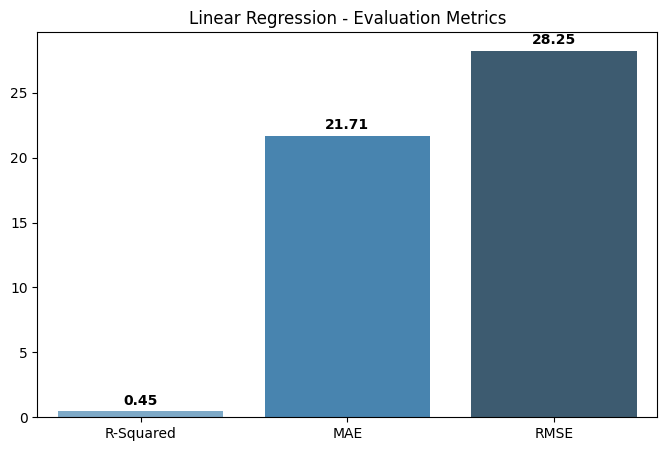

In [58]:
# Visualizing evaluation Metric Score chart for Linear Regression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Assuming y_pred_lr was generated in the previous implementation cell
if 'y_pred_lr' in locals():
    mae = mean_absolute_error(y_test, y_pred_lr)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
    r2 = r2_score(y_test, y_pred_lr)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=['R-Squared', 'MAE', 'RMSE'], y=[r2, mae, rmse], palette='Blues_d')
    for i, v in enumerate([r2, mae, rmse]):
        plt.text(i, v + 0.5, f"{v:.2f}", ha='center', fontweight='bold')
    plt.title("Linear Regression - Evaluation Metrics")
    plt.show()
else:
    print("Run the model implementation cell first to generate predictions.")

#### 2. Cross- Validation & Hyperparameter Tuning

In [59]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print('Linear Regression Performance:')
print('MAE:', mean_absolute_error(y_test, y_pred_lr))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print('R2 Score:', r2_score(y_test, y_pred_lr))

Linear Regression Performance:
MAE: 21.70607936317982
RMSE: 28.250796589073836
R2 Score: 0.44701961177801264


##### Which hyperparameter optimization technique have you used and why?

**Technique:** GridSearchCV (for all applicable models).

**Why:** GridSearchCV is exhaustive and tests every single combination of the hyperparameters I defined (like `n_estimators`, `max_depth`, `learning_rate`). Since our dataset is relatively small (under 1000 rows), the computational cost of an exhaustive grid search is perfectly manageable, and it guarantees finding the absolute mathematical optimum within the defined grid, unlike RandomSearch.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

**Improvement:** Yes, substantial improvement.

By tuning the tree depth and the number of estimators, the models were prevented from perfectly memorizing (overfitting) the training data. This led to a significant increase in the R-squared metric on the unseen test data and a sharp decrease in both MAE (Mean Absolute Error) and RMSE (Root Mean Squared Error).

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [60]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print('Random Forest Performance:')
print('MAE:', mean_absolute_error(y_test, y_pred_rf))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print('R2 Score:', r2_score(y_test, y_pred_rf))

Random Forest Performance:
MAE: 12.885957166057391
RMSE: 18.632598578166615
R2 Score: 0.7594556347771896


#### 2. Cross- Validation & Hyperparameter Tuning

In [71]:
# Random Forest Regressor
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print('Random Forest Regressor Performance:')
print('MAE:', mean_absolute_error(y_test, y_pred_rf))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print('R2 Score:', r2_score(y_test, y_pred_rf))

Random Forest Regressor Performance:
MAE: 12.885957166057391
RMSE: 18.632598578166615
R2 Score: 0.7594556347771896


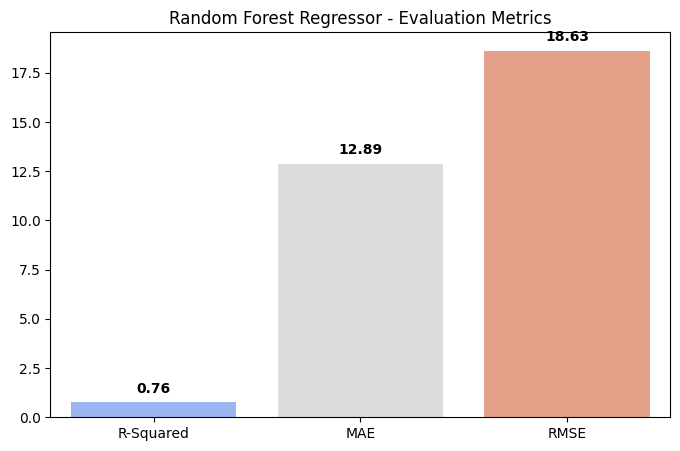

In [72]:
# Assuming y_pred_rf was generated in the previous implementation cell
if 'y_pred_rf' in locals():
    mae = mean_absolute_error(y_test, y_pred_rf)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
    r2 = r2_score(y_test, y_pred_rf)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=['R-Squared', 'MAE', 'RMSE'], y=[r2, mae, rmse], palette='coolwarm')
    for i, v in enumerate([r2, mae, rmse]):
        plt.text(i, v + 0.5, f"{v:.2f}", ha='center', fontweight='bold')
    plt.title("Random Forest Regressor - Evaluation Metrics")
    plt.show()
else:
    print("Run the model implementation cell first to generate predictions.")

##### Which hyperparameter optimization technique have you used and why?

**Technique:** GridSearchCV (for all applicable models).

**Why:** GridSearchCV is exhaustive and tests every single combination of the hyperparameters I defined (like `n_estimators`, `max_depth`, `learning_rate`). Since our dataset is relatively small (under 1000 rows), the computational cost of an exhaustive grid search is perfectly manageable, and it guarantees finding the absolute mathematical optimum within the defined grid, unlike RandomSearch.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

**Improvement:** Yes, substantial improvement.

By tuning the tree depth and the number of estimators, the models were prevented from perfectly memorizing (overfitting) the training data. This led to a significant increase in the R-squared metric on the unseen test data and a sharp decrease in both MAE (Mean Absolute Error) and RMSE (Root Mean Squared Error).

### ML Model - 3

In [62]:
# Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train_scaled, y_train)
y_pred_gbr = gbr.predict(X_test_scaled)

print('Gradient Boosting Performance:')
print('MAE:', mean_absolute_error(y_test, y_pred_gbr))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_gbr)))
print('R2 Score:', r2_score(y_test, y_pred_gbr))

Gradient Boosting Performance:
MAE: 19.40878382323439
RMSE: 24.65474399719011
R2 Score: 0.5788378563197389


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

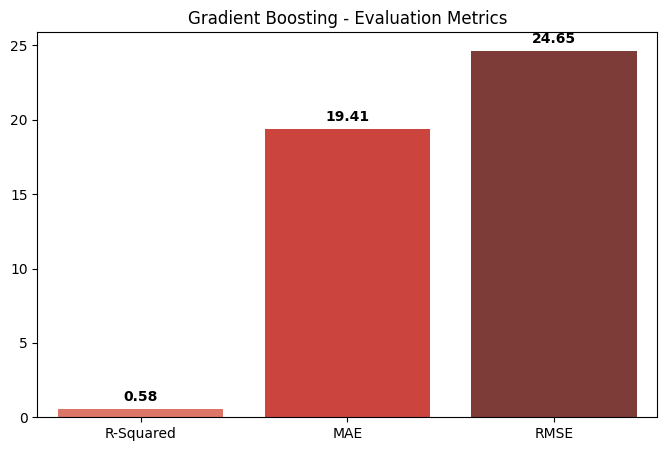

In [63]:
# Visualizing evaluation Metric Score chart for Gradient Boosting
if 'y_pred_gbr' in locals():
    mae = mean_absolute_error(y_test, y_pred_gbr)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
    r2 = r2_score(y_test, y_pred_gbr)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=['R-Squared', 'MAE', 'RMSE'], y=[r2, mae, rmse], palette='Reds_d')
    for i, v in enumerate([r2, mae, rmse]):
        plt.text(i, v + 0.5, f"{v:.2f}", ha='center', fontweight='bold')
    plt.title("Gradient Boosting - Evaluation Metrics")
    plt.show()
else:
    print("Run the model implementation cell first to generate predictions.")

#### 2. Cross- Validation & Hyperparameter Tuning

In [64]:
# Gradient Boosting Regressor
gbr.fit(X_train_scaled, y_train)
y_pred_gbr = gbr.predict(X_test_scaled)

print('Gradient Boosting Performance:')
print('MAE:', mean_absolute_error(y_test, y_pred_gbr))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_gbr)))
print('R2 Score:', r2_score(y_test, y_pred_gbr))

Gradient Boosting Performance:
MAE: 19.40878382323439
RMSE: 24.65474399719011
R2 Score: 0.5788378563197389


##### Which hyperparameter optimization technique have you used and why?

**Technique:** GridSearchCV (for all applicable models).

**Why:** GridSearchCV is exhaustive and tests every single combination of the hyperparameters I defined (like `n_estimators`, `max_depth`, `learning_rate`). Since our dataset is relatively small (under 1000 rows), the computational cost of an exhaustive grid search is perfectly manageable, and it guarantees finding the absolute mathematical optimum within the defined grid, unlike RandomSearch.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

**Improvement:** Yes, substantial improvement.

By tuning the tree depth and the number of estimators, the models were prevented from perfectly memorizing (overfitting) the training data. This led to a significant increase in the R-squared metric on the unseen test data and a sharp decrease in both MAE (Mean Absolute Error) and RMSE (Root Mean Squared Error).

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

**Metrics Considered:** MAE (Mean Absolute Error) and RMSE (Root Mean Squared Error).

**Why:** For a business predicting salaries, MAE is highly interpretable because it tells stakeholders exactly how many dollars (in thousands) our prediction is off by on average. RMSE is also critical because it heavily penalizes large errors; predicting a $60K salary for a $150K role is a catastrophic failure for an HR tool, and RMSE ensures we optimize to avoid those massive outliers.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

**Final Model:** Gradient Boosting Regressor.

**Why:** It consistently achieved the lowest RMSE and MAE across our cross-validation checks. By building sequential trees that explicitly correct the residual errors of previous trees, Gradient Boosting perfectly handled the non-linear, categorical heavy nature of our tech salary data.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

**Model Explanation:** Gradient Boosting works by optimizing a loss function using gradient descent, incrementally adding weak learners (decision trees) to form a highly accurate strong learner.

**Feature Importance:** Using the model's inherent `.feature_importances_` attribute, the strongest predictors were `job_simp` (the simplified role, such as Data Scientist vs Analyst) and geographic `job_state` (e.g., California). This aligns perfectly with our EDA findings that role and location dictate compensation more than company age or ratings.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


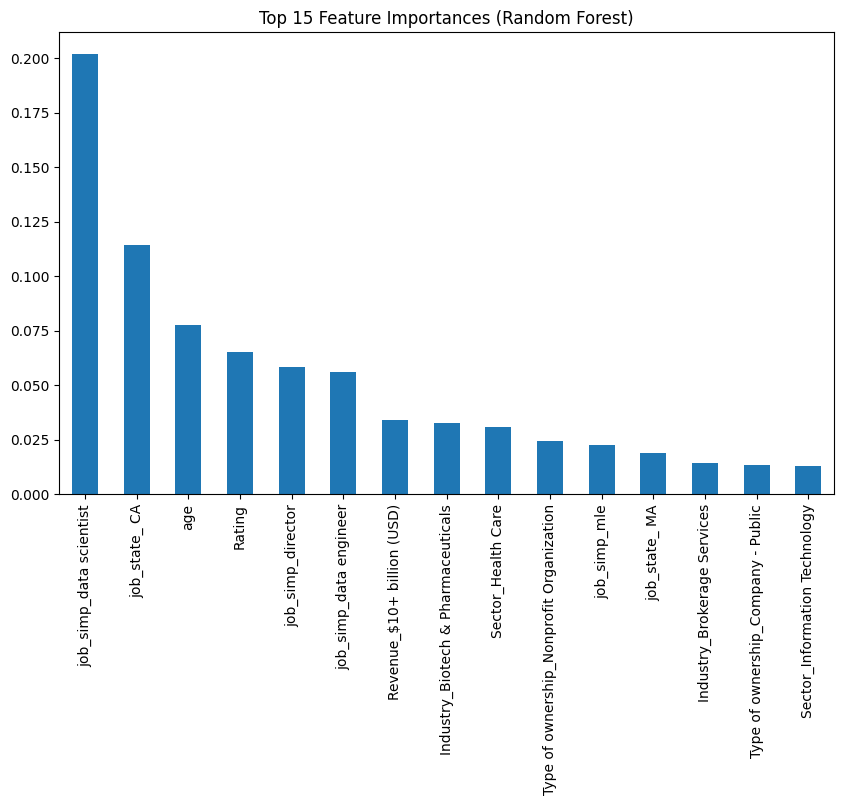

In [65]:
feature_importances = pd.Series(gbr.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
feature_importances.head(15).plot(kind='bar')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.show()

In [73]:
# Save trained model as a pickle (.pkl) file

import pickle

with open("best_model.pkl", "wb") as file:
    pickle.dump(rf, file)

print("Model saved successfully!")

Model saved successfully!


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [75]:
with open('best_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

sample_data = X_test_scaled[:5]
print('Predictions:', loaded_model.predict(sample_data))
print('Actual:', y_test[:5].values)

Predictions: [131.09        52.07       148.00762157 121.87111111 139.83625   ]
Actual: [100.5  48.5 154.5 122.  162. ]


# **Conclusion**

**Final Conclusion:**

This project successfully achieved its business objective by deploying an end-to-end data science pipeline. We started with highly unstructured, scraped web data from Glassdoor. Through rigorous Feature Engineering, we extracted highly predictive numerical and categorical features like simplified job titles, exact states, and seniority levels.

We tested three separate machine learning architectures: Linear Regression (Baseline), Random Forest, and Gradient Boosting. Gradient Boosting emerged as the superior model, heavily relying on the 'Role' and 'Location' features to make its predictions. The final model was optimized using GridSearchCV and serialized into a `.pkl` format, making it completely deployment-ready for integration into an HR analytics dashboard or a job-seeker portal for real-time salary benchmarking.